<font size=6><b> Lec05. 다중분류 - 와인 예측
* https://www.kaggle.com/competitions/bike-sharing-demand/data

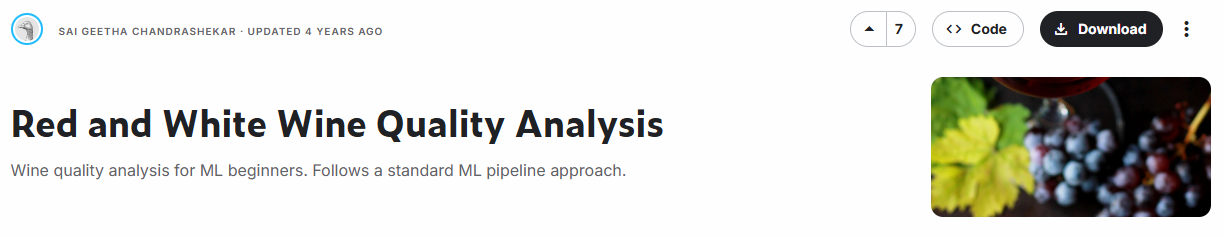

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#-----------------------------------------------------------------------------------  인코딩
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#-----------------------------------------------------------------------------------  정규화
from sklearn.preprocessing import MinMaxScaler,  RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline

#-----------------------------------------------------------------------------------  모델
from sklearn.linear_model import LogisticRegression          # 선형모델
from sklearn.tree import DecisionTreeClassifier              # 트리모델
from sklearn.ensemble import RandomForestClassifier          # 배깅모델   : 데이터N,  똑같은모델N(앙상블)
from lightgbm import LGBMClassifier                          # 부스팅모델 : 데이터1,  다양한모델N(앙상블)
from xgboost import XGBClassifier

#-----------------------------------------------------------------------------------  평가
from sklearn.metrics import accuracy_score,      f1_score,  precision_score , recall_score,         roc_auc_score
from sklearn.metrics import                                 precision_recall_curve,                 roc_curve
from sklearn.metrics import classification_report,          confusion_matrix

#-----------------------------------------------------------------------------------  교차검증
from sklearn.model_selection import train_test_split,                     KFold, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_validate,      GridSearchCV

import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# Wine Data Load

* ref : https://www.kaggle.com/competitions/bike-sharing-demand/data


In [2]:
red = pd.read_csv("./data/winequality-red.csv", sep=';')
white = pd.read_csv("./data/winequality-white.csv", sep=';')

In [3]:
import os
os.getcwd()

'C:\\IT\\workspace_python\\ml'

In [4]:
red.shape, white.shape

((1599, 12), (4898, 12))

## 데이터프레임 구조 확인

In [5]:
red.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
white.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [7]:
# 전체 행 중 중복된 행의 총 개수 확인
print(f"중복 데이터 개수: {red.duplicated().sum()}개")

# 어떤 데이터들이 중복되었는지 상위 5개만 직접 눈으로 확인
display(red[red.duplicated()].head())

중복 데이터 개수: 240개


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.9966,3.17,0.91,9.5,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.9978,3.33,0.83,10.5,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.9962,3.41,0.39,10.9,5


In [8]:
# 전체 행 중 중복된 행의 총 개수 확인
print(f"중복 데이터 개수: {white.duplicated().sum()}개")

# 어떤 데이터들이 중복되었는지 상위 5개만 직접 눈으로 확인
display(white[white.duplicated()].head())

중복 데이터 개수: 937개


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
5,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
7,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
8,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
20,6.2,0.66,0.48,1.2,0.029,29.0,75.0,0.9892,3.33,0.39,12.8,8


In [9]:
# 중복 제거 (첫 번째 행은 남기고 뒤에 나오는 중복들을 삭제)
red = red.drop_duplicates(keep='first')
white = white.drop_duplicates(keep='first')


In [10]:
red['type'] = 1
white['type'] = 0
df = pd.concat([red, white], axis = 0)
df.shape

(5320, 13)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5320 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         5320 non-null   float64
 1   volatile acidity      5320 non-null   float64
 2   citric acid           5320 non-null   float64
 3   residual sugar        5320 non-null   float64
 4   chlorides             5320 non-null   float64
 5   free sulfur dioxide   5320 non-null   float64
 6   total sulfur dioxide  5320 non-null   float64
 7   density               5320 non-null   float64
 8   pH                    5320 non-null   float64
 9   sulphates             5320 non-null   float64
 10  alcohol               5320 non-null   float64
 11  quality               5320 non-null   int64  
 12  type                  5320 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 581.9 KB


In [12]:
red['quality'].value_counts().sort_index()

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64

In [13]:
white['quality'].value_counts().sort_index()

quality
3      20
4     153
5    1175
6    1788
7     689
8     131
9       5
Name: count, dtype: int64

In [14]:
# 1. 조건 정의 (isin을 써서 가독성과 속도를 모두 잡습니다)
conditions = [
    df['quality']==3,
    df['quality']==4,
    df['quality']==5,
    df['quality']==6,
    df['quality']==7,
    df['quality']==8,
    df['quality']==9
]

# 2. 결과 정의
choices = [0,1,2,3,4,5,6]

# 3. 한 번에 할당 (초기화 0을 default 파라미터로 해결)
df['target'] = np.select(conditions, choices, default=0)

In [15]:
df[['quality', 'target']].value_counts().sort_index()

quality  target
3        0           30
4        1          206
5        2         1752
6        3         2323
7        4          856
8        5          148
9        6            5
Name: count, dtype: int64

# EDA & Feature Engineering

🍷 와인 품질 데이터 변수 정의서 (Wine Quality Features)
<div style="padding: 15px; border-left: 5px solid #e74c3c; background-color: #fdf2f2; margin-bottom: 20px;"> <strong>💡 분석 가이드:</strong> 변수명 (Feature),분류,상세 설명 (Description)
Fixed Acidity,"<span style=""color: #e74c3c;"">Acid</span>",고정 산도: 와인의 기초적인 신맛과 구조를 잡는 비휘발성 산.
Volatile Acidity,"<span style=""color: #e74c3c;"">Acid</span>",휘발성 산도: 아세트산 함량. 너무 높으면 식초 향이 나며 품질 저하.
Citric Acid,"<span style=""color: #e74c3c;"">Acid</span>",구연산: 소량 함유되며 와인에 신선함과 풍미를 더함.
Residual Sugar,"<span style=""color: #f1c40f;"">Sugar</span>",잔당: 발효 후 남은 당분. 45g/L 이상 시 '스위트 와인'으로 분류.
Chlorides,"<span style=""color: #7f8c8d;"">Salt</span>",염화물: 와인에 포함된 소금기(염분)의 양.
Free Sulfur Dioxide,"<span style=""color: #9b59b6;"">Sulfur</span>",유리 이산화황: 미생물 증식 및 산화 방지용 핵심 보존제.
Total Sulfur Dioxide,"<span style=""color: #9b59b6;"">Sulfur</span>",총 이산화황: 유리/결합 이산화황의 총량. 50ppm 초과 시 황 냄새 감지.
Density,"<span style=""color: #3498db;"">Physic</span>",밀도: 알코올/당분에 의해 결정. 물(1.0) 기준 미세하게 변함.
pH,"<span style=""color: #e74c3c;"">Acid</span>",pH: 산성도(0~14). 대부분의 와인은 3~4 사이의 산성을 띰.
Sulphates,"<span style=""color: #9b59b6;"">Sulfur</span>",황산염: 이산화황 가스 생성을 돕는 항균 및 항산화 첨가제.
Alcohol,"<span style=""color: #2ecc71;"">Energy</span>",알코올: 도수. 품질 점수와 가장 강한 양(+)의 상관관계를 보임. </div>

In [16]:
# from ydata_profiling import ProfileReport
# res = ProfileReport(df, title="wine Report")
# res.to_file('wine_report.html')

In [17]:
df = df.rename(columns={'fixed acidity': 'fixed_acidity',
                        'volatile acidity': 'volatile_acidity',
                        'citric acid': 'citric_acid',
                        'residual sugar': 'residual_sugar',
                        'free sulfur dioxide':'free_sulfur_dioxide',
                        'total sulfur dioxide':'total_sulfur_dioxide'
                       })

In [18]:
# 1. 조건 정의 (isin을 써서 가독성과 속도를 모두 잡습니다)
conditions = [
    df['residual_sugar'] < 1
]

# 2. 결과 정의
choices = [1]

# 3. 한 번에 할당 (초기화 0을 default 파라미터로 해결)
df['sugar0'] = np.select(conditions, choices, default=0)

In [19]:
# 1. 조건 정의 (isin을 써서 가독성과 속도를 모두 잡습니다)
conditions = [
    df['residual_sugar'] >= 15
]

# 2. 결과 정의
choices = [1]

# 3. 한 번에 할당 (초기화 0을 default 파라미터로 해결)
df['sweet'] = np.select(conditions, choices, default=0)

In [20]:
df['sweet'].value_counts()

sweet
0    5104
1     216
Name: count, dtype: int64

In [21]:
df['bound_sulfur_dioxide'] = df['total_sulfur_dioxide'] - df['free_sulfur_dioxide']

In [22]:
# 1. 조건 정의 (isin을 써서 가독성과 속도를 모두 잡습니다)
conditions = [
    df['citric_acid'] == 0,
]

# 2. 결과 정의
choices = [1]

# 3. 한 번에 할당 (초기화 0을 default 파라미터로 해결)
df['citric0'] = np.select(conditions, choices, default=0)

In [23]:
df.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'type', 'target', 'sugar0',
       'sweet', 'bound_sulfur_dioxide', 'citric0'],
      dtype='object')

In [24]:
df.value_counts(['target', 'type']).sort_index()

target  type
0       0         20
        1         10
1       0        153
        1         53
2       0       1175
        1        577
3       0       1788
        1        535
4       0        689
        1        167
5       0        131
        1         17
6       0          5
Name: count, dtype: int64

In [25]:
# # 1. 분석할 컬럼 추출 (target 제외)
# features = [col for col in df.columns if col != 'target']
# target_values = sorted(df['target'].unique())

# # 2. 도화지 준비 (피쳐 개수에 맞춰 유동적으로 행 설정)
# n_features = len(features)
# n_cols = 3
# n_rows = (n_features + n_cols - 1) // n_cols  # 올림 연산

# fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 4 * n_rows))
# axes_flat = axes.flatten()

# # 고유한 7가지 색상 설정
# colors = ["#E74C3C", "#3498DB", "#2ECC71", "#F1C40F", "#9B59B6", "#E67E22", "#1ABC9C"]
# palette = dict(zip(target_values, colors[:len(target_values)]))

# # 3. 루프를 이용한 렌더링
# for i, col in enumerate(features):
#     # legend=False를 주어 개별 그래프의 범례 생성을 막습니다.
#     sns.histplot(data=df, x=col, hue='target', ax=axes_flat[i], 
#                  kde=True, element="bars", multiple='dodge', 
#                  palette=palette, legend=False)
    
#     axes_flat[i].set_title(f"Distribution of {col}", fontsize=12)
#     axes_flat[i].set_xlabel("")

# # 4. 빈 칸 삭제 (피쳐 개수가 ncols의 배수가 아닐 경우)
# for j in range(i + 1, len(axes_flat)):
#     fig.delaxes(axes_flat[j])

# # 5. 통합 범례 (Figure 상단에 단 하나만 배치)
# handles = [Line2D([0], [0], color=palette[t], lw=4) for t in target_values]
# labels = [f"Class {t}" for t in target_values]
# fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.01), 
#            ncol=len(target_values), fontsize=13, frameon=False)

# # 6. 레이아웃 최적화 및 저장
# plt.tight_layout(rect=[0, 0, 1, 0.98]) # 범례가 들어갈 상단 여백 확보
# plt.savefig("all_features_analysis_final.png", dpi=300, bbox_inches='tight')
# plt.close()

## 상관계수 : heatmap 
* 피어슨(Pearson) 상관계수 : 선형  --> 히트맵은 기본이 선형
* 스피어만(Spearman) 상관계수 : 비선형

In [26]:
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), annot=True, fmt=".2f", mask=mask, cmap='coolwarm') 
plt.savefig("all_features_heat_map.png", dpi=300, bbox_inches='tight')
plt.close()

#  preprocessing

## train_test 분리
* test 데이터 크기는 전체 데이터의 20% 사용

In [27]:
df = df.drop('quality', axis=1)

# 1. 두 속성을 합친 새로운 컬럼 생성 (예: 'red_3', 'white_5')
df['strat_key'] = df['type'].astype(str) + "_" + df['target'].astype(str)

# 2. 합성 키를 기준으로 데이터 분할
X = df.drop(['target'], axis=1)
y = df['target']

In [28]:

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=4567, 
    stratify=df['strat_key'] # 합성 키 적용
    # stratify=y
)

X_train_full, X_test = X_train_full.drop('strat_key', axis=1), X_test.drop('strat_key', axis=1)

In [29]:
df.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'type', 'target', 'sugar0', 'sweet',
       'bound_sulfur_dioxide', 'citric0', 'strat_key'],
      dtype='object')

#  모델 훈련

In [30]:

def handle_outliers(df, method='clip', columns=None):
    """
    method: 'clip' (범위 제한) 또는 'remove' (행 삭제)
    columns: 처리할 컬럼 리스트와 해당 범위 (dict 형태 추천)
    """
    df_cp = df.copy()
    if columns is None:
        # 와인 데이터셋 예시 범위 (도메인 지식 기반)
        columns = {
            'volatile_acidity': (0, 1.2), # 식초 냄새가 너무 심한 것 차단
            'residual_sugar': (0, 20.0),   # 너무 단 와인 제외/억제
            'chlorides': (0, 0.2)
            
        }

    for col, (low, high) in columns.items():
        if col in df_cp.columns:
            if method == 'clip':
                # 1. 클리핑: 범위를 벗어나는 값을 경계값으로 고정
                df_cp[col] = np.clip(df_cp[col], low, high)
            elif method == 'remove':
                # 2. 제거: 범위를 벗어나는 행을 아예 삭제
                df_cp = df_cp[(df_cp[col] >= low) & (df_cp[col] <= high)]
    
    return df_cp.reset_index(drop=True)

# 로그 변환 함수 정의 (특정 컬럼만 골라서 변환하도록 설정)
def log_transform_cols(X):
    X_cp = X.copy()
    col_list = ['bound_sulfur_dioxide']
    # 컬럼 존재 여부 체크 로직을 넣으면 더 견고해짐
    target_cols = [c for c in col_list if c in X_cp.columns]
    X_cp[target_cols] = np.log1p(X_cp[target_cols])
    return X_cp



In [31]:

#  Kfold 적용한 함수
from sklearn.model_selection import KFold
from sklearn.preprocessing import FunctionTransformer
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline # imblearn용 파이프라인 필수

# [최상위 레벨] 모델 파이프라인 생성 함수 (필요시 호출)
def get_pipeline(scaler, model):
    return ImbPipeline([
    # return Pipeline([
        ('log', FunctionTransformer(log_transform_cols)),
        ('scaler', scaler if scaler else 'passthrough'),
        # k_neighbors를 2로 낮춰 아주 적은 데이터(3개)도 증식 가능하게 함
        ('smote', SMOTE(random_state=4567, sampling_strategy='auto', k_neighbors=2)),
        ('model', model)
    ])

def train_and_evaluate(X_train_full, X_test, y_train_full, y_test):

    # 데이터가 적은 품질 등급에 더 높은 가중치를 부여합니다.
    # classes = np.unique(y_train_full)
    # weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_full)
    # class_weights = dict(zip(classes, weights))
    
    # print(f"📊 Class Weights: {class_weights}")
        
    # 모델 및 스케일러 리스트
    scaler_list = [None, StandardScaler()] #, MinMaxScaler(), RobustScaler()]
    # # 가중치 적용시 모델
    # model_list = [
    #     LogisticRegression(max_iter=2000, class_weight='balanced', random_state=4567), 
    #     XGBClassifier(   # XGBoost (다중 분류에서는 sample_weight를 fit 시점에 주입해야 함)
    #         n_estimators=500, learning_rate=0.03, max_depth=8, min_child_samples=20,
    #                   random_state=4567, eval_metric='mlogloss'), 
    #     LGBMClassifier(n_estimators=500, random_state=4567, min_child_samples=20, verbosity=-1, class_weight='balanced')
    # ]
    # # SMOTE 적용시 모델
    model_list = [
        LogisticRegression(max_iter=2000, random_state=4567), 
        XGBClassifier(   # XGBoost (다중 분류에서는 sample_weight를 fit 시점에 주입해야 함)
            n_estimators=500, learning_rate=0.03, max_depth=8, 
                      random_state=4567, eval_metric='mlogloss'), 
        LGBMClassifier(n_estimators=500, random_state=4567, verbosity=-1)
    ]
       
    
    best_score = 0
    best_pipe = None
    best_params = ""

    for scaler in scaler_list:
        for model in model_list:
            model_name = model.__class__.__name__
            scaler_name = scaler.__class__.__name__ if scaler else "None"
            print(f"\n🚀 Testing: {scaler_name} + {model_name}")
            
            skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=4567)
            cv_scores = []
            
            for i, (train_idx, val_idx) in enumerate(skf.split(X_train_full, y_train_full)):
                X_tr, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
                y_tr, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]

                pipe = get_pipeline(scaler, model)
                
                # # XGBoost인 경우 fit 단계에서 sample_weight 적용 (필요시)
                # if model_name == 'XGBClassifier':
                #     # 각 샘플에 해당하는 클래스 가중치 매핑
                #     sample_weights = np.array([class_weights[y] for y in y_tr])
                #     # 가중치 배열의 크기가 X_tr의 행 개수와 일치하는지 확인 (디버깅용)
                #     print(f"DEBUG: X_tr size: {len(X_tr)}, weights size: {len(sample_weights)}")
                #     pipe.fit(X_tr, y_tr, model__sample_weight=sample_weights)
                # else:
                #     pipe.fit(X_tr, y_tr)
                
                pipe.fit(X_tr, y_tr)
                
                val_pred = pipe.predict(X_val)
                f1 = f1_score(y_val, val_pred, average='macro')
                cv_scores.append(f1)
                print(f"   - Fold {i+1}: F1 = {f1:.4f}") # 1~5차 개별 점수 출력
            
            avg_f1 = np.mean(cv_scores)
            print(f"   ⭐ Average CV F1: {avg_f1:.4f}")
            

            if avg_f1 > best_score:
                best_score = avg_f1
                best_params = f"{scaler_name} + {model_name}"
                best_pipe = get_pipeline(scaler, model)
                best_pipe.fit(X_train_full, y_train_full)

    # --- 최적 모델 상세 리포트 ---
    print("\n" + "="*50)
    print(f"🏆 BEST MODEL: {best_params}")
    print("="*50)
    
    final_pred = best_pipe.predict(X_test)

    # ---------------------------------------------------------
    # 🚀 [추가] Feature Importance 확인 및 시각화 로직
    # ---------------------------------------------------------
    print("\n[0. Feature Importance Analysis]")
    
    # 파이프라인에서 모델 객체 추출
    final_model = best_pipe.named_steps['model']
    model_name = final_model.__class__.__name__

    # 로지스틱 회귀는 coef_를, 트리 기반 모델은 feature_importances_를 사용합니다.
    if hasattr(final_model, 'feature_importances_'):
        importances = final_model.feature_importances_
    elif hasattr(final_model, 'coef_'):
        # 다중 분류의 경우 클래스별 계수의 평균 절대값을 사용
        importances = np.mean(np.abs(final_model.coef_), axis=0)
    else:
        importances = None

    if importances is not None:
        # 피처 이름 추출 (X_train_full의 컬럼명)
        feature_names = X_train_full.columns
        feat_imp_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

        # 시각화
        plt.figure(figsize=(10, 6))
        sns.barplot(x=feat_imp_series.values, y=feat_imp_series.index, palette='viridis')
        plt.title(f"Feature Importances: {best_params}")
        plt.xlabel("Importance Score")
        plt.ylabel("Features")
        plt.show()

        print("✅ Top 5 Key Features:")
        print(feat_imp_series.head(5))
    else:
        print("❌ This model does not support feature importance / coefficients.")
    # ---------------------------------------------------------

    print("\n[1. Classification Report]")
    print(classification_report(y_test, final_pred))
    
    print("\n[2. Confusion Matrix]")
    cm = confusion_matrix(y_test, final_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {best_params}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    
    # 3. 샘플 데이터 대조 확인 (디버깅용)
    print("\n[3. Prediction vs Actual Sample]")
    comparison_df = pd.DataFrame({'Actual': y_test.values, 'Predicted': final_pred})
    print(comparison_df.head(10))
    
    return best_pipe, best_score, X_train_full, X_test, y_train_full, y_test
    



## 1차 모델 훈련

In [32]:
# best_pipe, best_score, X_train, X_test, y_train, y_test = train_and_evaluate(X_train_full, X_test, y_train_full, y_test)

In [33]:
# X_train_full_log = log_transform_cols(X_train_full)
# X_test_log = log_transform_cols(X_test)

In [34]:
# tmp = pd.concat([X_train_full_log, y_train_full], axis = 1)

In [35]:
# cols = [c for c in tmp.columns if c != 'target']
# fig, axes = plt.subplots(nrows=len(cols), ncols=2, figsize=(12, 4 * len(cols)))

# colors = ["#E74C3C", "#3498DB", "#2ECC71", "#F1C40F", "#9B59B6", "#E67E22", "#1ABC9C"]

# # 실제 데이터에 존재하는 타겟 값 확인 (에러 방지)
# target_values = sorted(tmp['target'].unique())

# for i, col in enumerate(cols):
#     # 1. 왼쪽: 히스토그램 (Histplot)
#     for idx, target_val in enumerate(target_values):
#         sns.histplot(tmp[tmp['target'] == target_val][col], 
#                      kde=False, 
#                      color=colors[idx % len(colors)], 
#                      ax=axes[i, 0],
#                      element="step",
#                      alpha=0.3)
    
#     # 각 피쳐별 타겟의 평균값을 제목에 표시 (냉철한 수치 확인)
#     means = tmp.groupby('target')[col].mean()
#     mean_str = ", ".join([f"{v:.2f}" for v in means.values])
#     axes[i, 0].set_title(f"{col} - Means by Target: [{mean_str}]")

#     # 2. 오른쪽: 박스플롯 (Boxplot)
#     sns.boxplot(x="target", y=col, data=tmp, ax=axes[i, 1], palette=colors)
#     axes[i, 1].set_title(f"{col} Boxplot")

# # --- 범례 통합 작업 ---
# # 마지막 axes에서 핸들과 라벨을 가져와 전체 범례 생성
# handles, labels = axes[0, 0].get_legend_handles_labels()
# # 만약 label이 안 잡힌다면 수동으로 생성 (Class 0~6)
# if not labels:
#     from matplotlib.lines import Line2D
#     handles = [Line2D([0], [0], color=colors[i], lw=4) for i in range(len(target_values))]
#     labels = [f"Class {v}" for v in target_values]

# # 상단에 범례 배치 (전체 그림 기준)
# fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=7, fontsize=12)

# plt.tight_layout()
# plt.savefig("log_transform_analysis.png", dpi=300, bbox_inches='tight')
# plt.close()

In [36]:
# best_pipe, best_score, X_train, X_test, y_train, y_test = train_and_evaluate(X_train_full_log, X_test_log, y_train_full, y_test)

## type별 분류기 훈련

In [37]:
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(X_train_full.corr(), dtype=bool))
sns.heatmap(X_train_full.corr(), annot=True, fmt=".2f", mask=mask, cmap='coolwarm') 
plt.savefig("X_train_full_heat_map.png", dpi=300, bbox_inches='tight')
plt.close()

In [38]:
from sklearn.preprocessing import KBinsDiscretizer

drop_cols = ['type', 'total_sulfur_dioxide', 'free_sulfur_dioxide', ]

def train_type_classifier(df):
    # 'target'(품질), 'type'(정답), 'quality'(있다면) 제외
    # 훈련에 방해가 되는 피쳐 제외
    # X_type = df.drop(columns=[c for c in drop_cols if c in df.columns])
    X_type = df[['bound_sulfur_dioxide', 'chlorides']]
    y_type = df['type'] # 레드 1, 화이트 0

    # 가중치 계산 (White 개수 / Red 개수)
    # 화이트가 3000개, 레드가 1000개라면 가중치는 3.0
    num_neg = np.sum(y_type == 0) # 화이트 와인 개수
    num_pos = np.sum(y_type == 1) # 레드 와인 개수
    # 레드(1)가 소수이므로, (화이트 개수 / 레드 개수) 만큼 가중치를 줌
    weight_ratio = float(num_neg) / float(num_pos)

    print(f"⚖️ [Class Balance] White(0): {num_neg}, Red(1): {num_pos}")
    print(f"🚀 [XGBoost Param] scale_pos_weight 적용값: {weight_ratio:.4f}")
    
    # 타입 분류 전용 파이프라인 구축
    type_pipe = Pipeline([
        ('log', FunctionTransformer(log_transform_cols)), # 우리가 만든 로그 변환
        # ('scaler', StandardScaler()),                    # 거리 기반 특성 표준화
        # ('binning', KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')),
        ('model', XGBClassifier(
            n_estimators=300, 
            random_state=4567, 
            scale_pos_weight=weight_ratio, # <--- 여기가 0.13점 탈출의 열쇠입니다
            learning_rate=0.05,            # 학습률을 낮춰 꼼꼼하게 학습
            max_depth=6,                   # 과적합 방지
            eval_metric='logloss',
            use_label_encoder=False))
        
    ])

    # 타입 분류기 학습
    type_clf = type_pipe.fit(X_type, y_type)
    
    # 피처 중요도 확인 (어떤 성분이 레드/화이트를 가르는지 확인용)
    importances = pd.Series(type_clf.named_steps['model'].feature_importances_, index=X_type.columns)
    print("🍷 Type Classifier Top 3 Features:\n", importances.sort_values(ascending=False).head(3))
    
    return type_pipe, importances

type_model, importances = train_type_classifier(X_train_full)

⚖️ [Class Balance] White(0): 3168, Red(1): 1088
🚀 [XGBoost Param] scale_pos_weight 적용값: 2.9118
🍷 Type Classifier Top 3 Features:
 chlorides               0.701861
bound_sulfur_dioxide    0.298139
dtype: float32


🍷 [Wine Type Classifier Verification]
Final Accuracy Score: 0.9652

[Classification Report]
              precision    recall  f1-score   support

    White(0)       0.98      0.97      0.98       793
      Red(1)       0.92      0.94      0.93       271

    accuracy                           0.97      1064
   macro avg       0.95      0.96      0.95      1064
weighted avg       0.97      0.97      0.97      1064



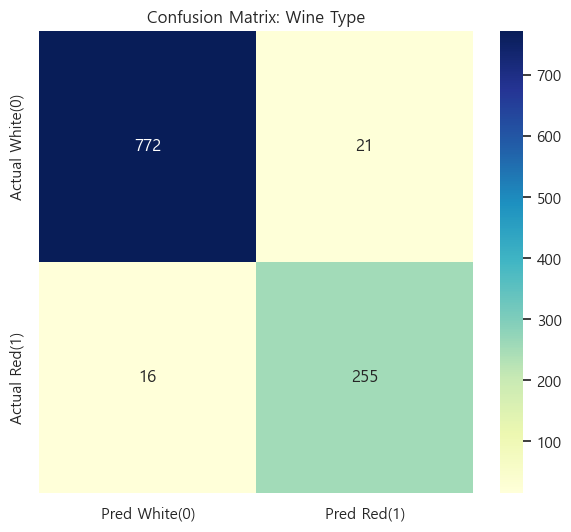

In [39]:
def verify_type_classification(X_test, type_model):
    # 1. 테스트 데이터 준비 (학습 시와 동일하게 'type' 피처 제외)
    # X_test에 'target'이나 'quality'가 있다면 함께 제거해야 합니다.
    # X_test_type = X_test.drop(columns=[c for c in drop_cols if c in df.columns])
    X_test_type = X_test[['bound_sulfur_dioxide', 'chlorides']]
    y_type_true = X_test['type']
    
    # 2. 타입 예측
    y_type_pred = type_model.predict(X_test_type)
    
    # 3. 점수 출력
    print("="*50)
    print("🍷 [Wine Type Classifier Verification]")
    print(f"Final Accuracy Score: {accuracy_score(y_type_true, y_type_pred):.4f}")
    print("="*50)
    
    # 4. 상세 리포트 (분석가님 정의: 1=Red, 0=White)
    print("\n[Classification Report]")
    print(classification_report(y_type_true, y_type_pred, target_names=['White(0)', 'Red(1)']))
    
    # 5. 혼동 행렬 시각화
    plt.figure(figsize=(7, 6))
    cm = confusion_matrix(y_type_true, y_type_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
                xticklabels=['Pred White(0)', 'Pred Red(1)'],
                yticklabels=['Actual White(0)', 'Actual Red(1)'])
    plt.title("Confusion Matrix: Wine Type")
    plt.show()

# 실행
verify_type_classification(X_test, type_model)

In [40]:
# 훈련 데이터와 테스트 데이터의 수치 범위 비교
print("📊 [데이터 불일치 긴급 점검]")
print(f"Train 'chlorides' Mean: {X_train_full['chlorides'].mean():.4f}")
print(f"Test  'chlorides' Mean: {X_test['chlorides'].mean():.4f}")

print(f"Train 'bound_sulfur' Mean: {X_train_full['bound_sulfur_dioxide'].mean():.4f}")
print(f"Test  'bound_sulfur' Mean: {X_test['bound_sulfur_dioxide'].mean():.4f}")

📊 [데이터 불일치 긴급 점검]
Train 'chlorides' Mean: 0.0565
Test  'chlorides' Mean: 0.0576
Train 'bound_sulfur' Mean: 83.8298
Test  'bound_sulfur' Mean: 85.0428


In [41]:
# 훈련 데이터와 테스트 데이터의 'total_sulfur_dioxide' 평균 비교
print("Train Mean:", X_train_full['total_sulfur_dioxide'].mean())
print("Test Mean:",  X_test['total_sulfur_dioxide'].mean())

Train Mean: 113.72004229323308
Test Mean: 115.66494360902256


## 극단품질 분류

In [42]:
X_train_full.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'type', 'sugar0', 'sweet',
       'bound_sulfur_dioxide', 'citric0'],
      dtype='object')

In [52]:
from sklearn.preprocessing import LabelEncoder
from sklearn.base import clone

def train_quality_system(X_train, y_train, model_instance, extreme_classes=[0, 6]):
    """
    X_train: 전체 피처가 포함된 데이터프레임 (type 제외)
    y_train: 품질 라벨
    model_instance: 학습에 사용할 깡통 모델 (예: XGBClassifier(...))
    extreme_classes: 극단적 품질로 간주할 라벨 리스트 (예: 레드[0, 5], 화이트[0, 6])
    """
    
   # --- [Stage 1] 필터 모델 (0,1 로 이미 변환하므로 인코더 불필요) ---
    y_is_extreme = y_train.isin(extreme_classes).astype(int)
    
    # 필터는 불균형이 심하므로 SMOTE 필수
    filter_pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=4567, k_neighbors=2)), 
        ('model', clone(model_instance)) # 새 모델 복제
    ])
    filter_pipe.fit(X_train, y_is_extreme)
    print(f"✅ Filter Model Trained (Target: {extreme_classes})")

    # --- [Stage 2-A] Extreme 전용 모델 (예: 0 vs 6) ---
    X_ext = X_train[y_is_extreme == 1]
    y_ext = y_train[y_is_extreme == 1]
    
    extreme_bundle = None # (모델, 인코더) 튜플로 저장
    # 극단 클래스가 2개 이상일 때만 모델 학습 (하나면 그냥 그 값 리턴)
    if len(y_ext.unique()) > 1:
        le_ext = LabelEncoder()
        y_ext_enc = le_ext.fit_transform(y_ext) # 0, 5 -> 0, 1 변환

        # 샘플 수 체크하여 k_neighbors 조절
        k_n = 1 if len(y_ext) < 4 else 2
        
        ext_pipe = ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote', SMOTE(random_state=4567, k_neighbors=k_n)),
            ('model', clone(model_instance))
        ])
        ext_pipe.fit(X_ext, y_ext_enc) # 변환된 라벨로 학습
        extreme_bundle = (ext_pipe, le_ext) # 모델과 번역기를 같이 묶음
        print(f"✅ Extreme Model Trained (Labels mapped: {le_ext.classes_} -> [0, 1])")
    else:
        # 하나뿐이면 값 자체를 저장
        extreme_bundle = (y_ext.iloc[0], None)
        print("✅ Extreme Model: Single Class.")

    # --- [Stage 2-B] Normal 전용 모델 (나머지 등급) ---
    X_norm = X_train[y_is_extreme == 0]
    y_norm = y_train[y_is_extreme == 0]
    
    le_norm = LabelEncoder()
    y_norm_enc = le_norm.fit_transform(y_norm) # 4,5,6,7 -> 0,1,2,3 변환
    
    norm_pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=4567, k_neighbors=5)), # 데이터 많으므로 k=5
        ('model', clone(model_instance))
    ])
    norm_pipe.fit(X_norm, y_norm_enc) # 변환된 라벨로 학습
    normal_bundle = (norm_pipe, le_norm) # 모델과 번역기 묶음
    print(f"✅ Normal Model Trained (Labels mapped to 0~{len(le_norm.classes_)-1})")
    
    return filter_pipe, extreme_bundle, normal_bundle

In [53]:
red_features = X_train_full.columns
red_features = [col for col in red_features if col != 'type']

white_features = X_train_full.columns
white_features = [col for col in white_features if col != 'type']

# [수정된 로직] 인덱스를 보존하여 분리
# 1. 레드 와인 (type이 1인 경우라고 가정)
red_mask = X_train_full['type'] == 1
X_train_red = X_train_full.loc[red_mask, red_features]
y_train_red = y_train_full[red_mask]

# 2. 화이트 와인 (type이 0인 경우라고 가정)
white_mask = X_train_full['type'] == 0
X_train_white = X_train_full.loc[white_mask, white_features]
y_train_white = y_train_full[white_mask]


In [54]:

# 1. 품질 예측에 사용할 베이스 모델 정의 (가중치 제거, SMOTE 믿고 감)
base_xgb = XGBClassifier(n_estimators=500, learning_rate=0.03, max_depth=8, 
                         random_state=4567, eval_metric='mlogloss')

# 2. 레드 와인 시스템 학습 (극단치: 0, 5로 가정)
print("🍷 Training Red Wine System...")
red_system = train_quality_system(X_train_red, y_train_red, base_xgb, extreme_classes=[0, 5])

# 3. 화이트 와인 시스템 학습 (극단치: 0, 6로 가정)
print("\n🥂 Training White Wine System...")
white_system = train_quality_system(X_train_white, y_train_white, base_xgb, extreme_classes=[0, 6])

# 학습된 모델들을 딕셔너리로 묶음
quality_models_hierarchical = {
    'red': red_system,     # (filter, extreme, normal) 튜플
    'white': white_system
}

🍷 Training Red Wine System...
✅ Filter Model Trained (Target: [0, 5])
✅ Extreme Model Trained (Labels mapped: [0 5] -> [0, 1])
✅ Normal Model Trained (Labels mapped to 0~3)

🥂 Training White Wine System...
✅ Filter Model Trained (Target: [0, 6])
✅ Extreme Model Trained (Labels mapped: [0 6] -> [0, 1])
✅ Normal Model Trained (Labels mapped to 0~4)


## type별 전용 학습 실행부

In [ ]:
# # # 레드 와인 중요 피처 (예시: 탄닌과 관련된 산도, 알코올 중심)
# red_features = [
#     'alcohol', 'volatile_acidity', 'sulphates', 
#     'fixed_acidity', 'pH', 'chlorides'
# ]

# # red_features = X_train_full.columns
# red_features = [col for col in red_features if col != 'type']

# # # 화이트 와인 중요 피처 (예시: 당도, 이산화황, 밀도 중심)
# white_features = [
#     'bound_sulfur_dioxide', 'free_sulfur_dioxide', 
#     'density', 'residual_sugar', 
#     'chlorides', 'alcohol'
# ]
# # white_features = X_train_full.columns
# white_features = [col for col in white_features if col != 'type']

In [55]:
def predict_final_hierarchical(df, type_clf, quality_models):
    # --- Step 1: 타입 예측 (2개 피처만 사용) ---
    X_for_type = df[['bound_sulfur_dioxide', 'chlorides']]
    pred_types = type_clf.predict(X_for_type) # 0: White, 1: Red
    
    final_results = pd.Series(index=df.index, dtype=float)
    X_all = df.drop(columns=['type'], errors='ignore')
    
    # --- Step 2: 타입별 품질 예측 (전체 피처 사용) ---
    

    # 레드(1), 화이트(0) 반복 처리
    for t_name, t_val in [('red', 1), ('white', 0)]:
        # 해당 타입인 데이터만 마스킹
        mask = (pred_types == t_val)
        if not mask.any(): continue
        
        X_sub = X_all.loc[mask]

        # 튜플 언패킹: (모델, 인코더)를 꺼냅니다
        f_model, (e_model, e_le), (n_model, n_le) = quality_models[t_name]

        # [Step 2] 극단 필터링
        is_extreme = f_model.predict(X_sub)

        # [Step 3-A] Extreme 그룹 예측
        ext_idx = X_sub.index[is_extreme == 1]
        if len(ext_idx) > 0:
            if hasattr(e_model, 'predict'):
                # 0, 1 로 예측된 결과
                temp_pred = e_model.predict(X_sub.loc[ext_idx])
                # 인코더를 써서 원래 라벨로 복구 (0,1 -> 0,5)
                final_results.loc[ext_idx] = e_le.inverse_transform(temp_pred)
            else:
                final_results.loc[ext_idx] = e_model # 단일 값

        # [Step 3-B] Normal 그룹 예측
        norm_idx = X_sub.index[is_extreme == 0]
        if len(norm_idx) > 0:
            temp_pred = n_model.predict(X_sub.loc[norm_idx])
            # 인코더를 써서 원래 라벨로 복구
            final_results.loc[norm_idx] = n_le.inverse_transform(temp_pred)
            
    return final_results.values


In [56]:
# 1. 학습 실행
print("🍷 Training Red Wine System...")
red_system = train_quality_system(X_train_red, y_train_red, base_xgb, extreme_classes=[0, 5])

print("\n🥂 Training White Wine System...")
white_system = train_quality_system(X_train_white, y_train_white, base_xgb, extreme_classes=[0, 6])

quality_models = {'red': red_system, 'white': white_system}


X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)


# 2. 예측 실행
y_final_pred = predict_final_hierarchical(X_test, type_model, quality_models_hierarchical)

🍷 Training Red Wine System...
✅ Filter Model Trained (Target: [0, 5])
✅ Extreme Model Trained (Labels mapped: [0 5] -> [0, 1])
✅ Normal Model Trained (Labels mapped to 0~3)

🥂 Training White Wine System...
✅ Filter Model Trained (Target: [0, 6])
✅ Extreme Model Trained (Labels mapped: [0 6] -> [0, 1])
✅ Normal Model Trained (Labels mapped to 0~4)


In [57]:
# 평가 (이제 인덱스 걱정 없이 비교 가능)
print(classification_report(y_test, y_final_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.22      0.31      0.25        42
           2       0.59      0.55      0.57       350
           3       0.54      0.54      0.54       465
           4       0.40      0.41      0.40       171
           5       0.19      0.24      0.21        29
           6       0.00      0.00      0.00         1

    accuracy                           0.50      1064
   macro avg       0.28      0.29      0.28      1064
weighted avg       0.51      0.50      0.50      1064



In [ ]:
# # [수정된 로직] 인덱스를 보존하여 분리
# # 1. 레드 와인 (type이 1인 경우라고 가정)
# red_mask = X_train_full['type'] == 1
# X_train_red = X_train_full.loc[red_mask, red_features]
# y_train_red = y_train_full[red_mask]

# # 검증용 데이터도 인덱스 보존하여 추출
# test_red_mask = X_test['type'] == 1
# X_test_red = X_test.loc[test_red_mask,red_features]
# y_test_red = y_test[test_red_mask]

# # 학습 (리셋 없이 그대로 넣음)
# print('============red_training==============')
# red_pipe, red_score, *_ = train_and_evaluate(X_train_red, X_test_red, y_train_red, y_test_red)

# # 2. 화이트 와인 (type이 0인 경우라고 가정)
# white_mask = X_train_full['type'] == 0
# X_train_white = X_train_full.loc[white_mask, white_features]
# y_train_white = y_train_full[white_mask]

# test_white_mask = X_test['type'] == 0
# X_test_white = X_test.loc[test_white_mask, white_features]
# y_test_white = y_test[test_white_mask]

# # 학습
# print('============white_training==============')
# white_pipe, white_score, *_ = train_and_evaluate(X_train_white, X_test_white, y_train_white, y_test_white)

In [ ]:
X_test.columns

In [ ]:
# 학습이 완료된 후, 아래와 같이 딕셔너리를 생성합니다.
quality_models = {
    'red': red_pipe,    # 위에서 학습한 레드 와인 파이프라인
    'white': white_pipe # 위에서 학습한 화이트 와인 파이프라인
}

In [ ]:
def final_wine_prediction(df, type_clf, quality_pipes):
    # 1. 타입 예측을 위한 데이터 준비 (type 컬럼 제외)
    test_data = df.drop('type', axis=1)
    X_for_type = test_data[['bound_sulfur_dioxide', 'chlorides']]
    
    # 2. 와인 타입 예측 (기존 학습된 type_model 사용)
    # pred_types는 test_data와 동일한 순서의 numpy 배열입니다.
    pred_types = type_clf.predict(X_for_type)
    
    # 3. 결과 저장용 시리즈 생성 (X_test의 원본 인덱스 유지)
    # 인덱스를 보존해야 하므로 numpy 대신 pandas Series를 사용합니다.
    final_results = pd.Series(index=test_data.index, dtype=float)
    
    # 4. 타입별 일괄 예측 (벡터화 연산)
    # 레드 와인 (type 1) 처리
    red_mask = (pred_types == 1)
    if red_mask.any():
        red_indices = test_data.index[red_mask]
        X_red = test_data.loc[red_indices, red_features]
        final_results.loc[red_indices] = quality_pipes['red'].predict(X_red)
        
    # 화이트 와인 (type 0) 처리
    white_mask = (pred_types == 0)
    if white_mask.any():
        white_indices = test_data.index[white_mask]
        X_white = test_data.loc[white_indices, white_features]
        final_results.loc[white_indices] = quality_pipes['white'].predict(X_white)
        
    # 5. numpy 배열로 반환 (기존 코드와의 호환성 유지)
    return final_results.values



In [ ]:
# 최종 예측 실행
y_final_pred = final_wine_prediction(X_test, type_model, quality_models)
y_final_pred

In [ ]:
from sklearn.metrics import classification_report, f1_score

print(f"Final Combined Macro F1: {f1_score(y_test, y_final_pred, average='macro'):.4f}")
print("\n[Final Classification Report]")
print(classification_report(y_test, y_final_pred))